Bu kısımda elimizdeki datasette bulunan verilerin çeşitli görselleştirmesini yapacağız.

In [1]:
import pandas as pd
import numpy as np
import csv
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [3]:
try:
    df = pd.read_csv("final_data2.csv",
                    sep=',',
                    on_bad_lines='skip',
                    engine='c',
                    quoting=csv.QUOTE_MINIMAL)
    print(f"Veri seti yüklendi. Satır sayısı: {len(df)}")
except:
    df = pd.read_csv("final_data2.csv", on_bad_lines='skip', engine='python')

Veri seti yüklendi. Satır sayısı: 20405


In [5]:
def extract_features_v2(text):
    text = str(text)
    words = text.split()
    num_words = len(words) if len(words) > 0 else 1
    text_len = len(text) if len(text) > 0 else 1

    # Mevcutlar
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    lexical_div = len(set(words)) / num_words
    caps_ratio = sum(1 for c in text if c.isupper()) / text_len
    excl_count = text.count('!')

    avg_word_len = sum(len(word) for word in words) / num_words # haberin ortalama kelime uzunluğu
    q_mark_count = text.count('?') # haberde kullanılan soru işareti sayısı
    digit_ratio = sum(c.isdigit() for c in text) / text_len # haberin sayısal karakter oranı

    return pd.Series([num_words, sentiment, subjectivity, lexical_div, caps_ratio, excl_count,
                      avg_word_len, q_mark_count, digit_ratio]) # seri olarak returnle

In [8]:
new_feature_names = ['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count',
                     'avg_word_len', 'q_mark_count', 'digit_ratio']

df[new_feature_names] = df['full_text'].apply(extract_features_v2)

Correlation Matrix Table:
              sentiment  subjectivity  lexical_div  word_count  avg_word_len  \
sentiment      1.000000      0.378984     0.034143    0.004639     -0.143202   
subjectivity   0.378984      1.000000    -0.039382    0.031158     -0.240788   
lexical_div    0.034143     -0.039382     1.000000   -0.591219      0.189471   
word_count     0.004639      0.031158    -0.591219    1.000000     -0.059968   
avg_word_len  -0.143202     -0.240788     0.189471   -0.059968      1.000000   
digit_ratio    0.021781     -0.077766    -0.052910    0.108952      0.305470   
caps_ratio     0.095003     -0.090301     0.216186   -0.049143      0.096405   
excl_count     0.137994      0.126516    -0.128895    0.273550     -0.088677   
q_mark_count   0.048281      0.108805    -0.266908    0.505315     -0.133613   

              digit_ratio  caps_ratio  excl_count  q_mark_count  
sentiment        0.021781    0.095003    0.137994      0.048281  
subjectivity    -0.077766   -0.090301    

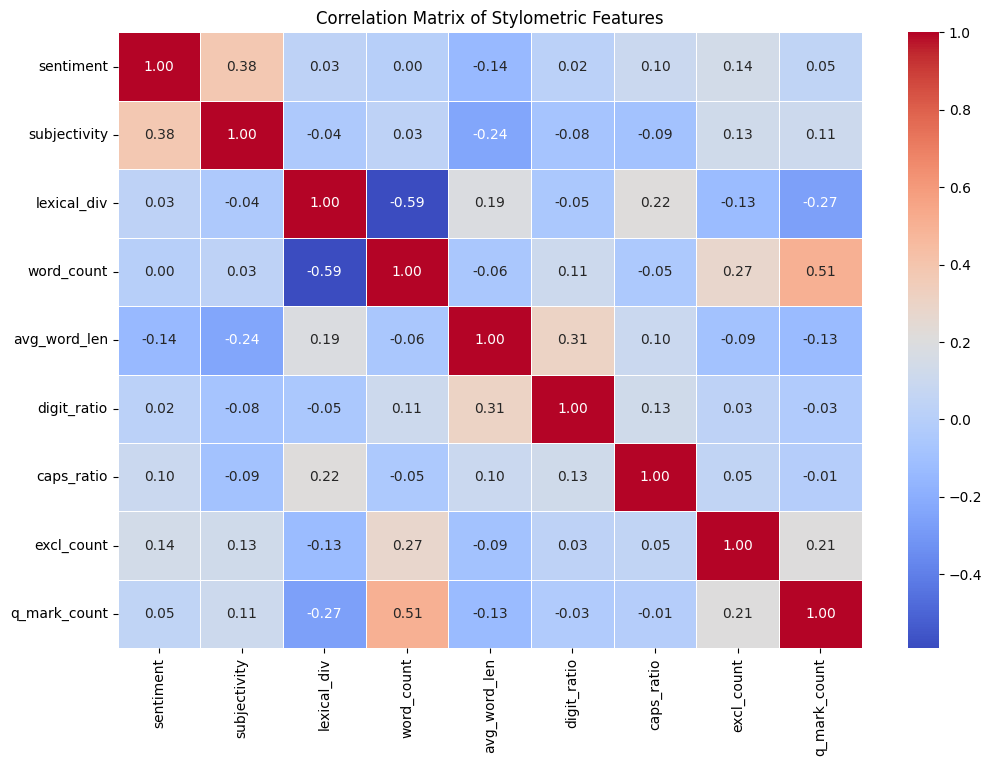

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'sentiment', 'subjectivity', 'lexical_div',
    'word_count', 'avg_word_len', 'digit_ratio',
    'caps_ratio', 'excl_count', 'q_mark_count'
]


corr_matrix = df[features].corr()


print("Correlation Matrix Table:")
print(corr_matrix)


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Stylometric Features')
plt.show()



En çok pozitif korelasyona sahip özellikler:

word_count - q_mark_count --> 0.51

subjectivity - sentiment --> 0.38

En çok negatif korelasyona sahip özellikler:

lexical - diversity --> -0.27

subjectivity - average_word_length --> -0.24

Sentiment Polarity Dağılımına Bakabiliriz

/tmp/ipython-input-3683417001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='sentiment', data=df, palette='Set2')


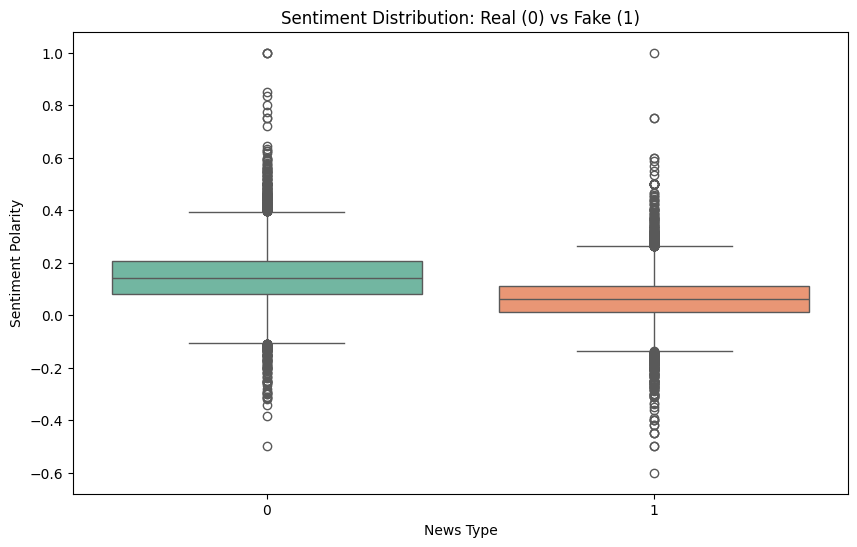

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution: Real (0) vs Fake (1)')
plt.xlabel('News Type')
plt.ylabel('Sentiment Polarity')
plt.show()

Genel olarak gerçek haberlerde sentiment biraz daha yüksek, ancak ikisinde de aykırı değerler var.

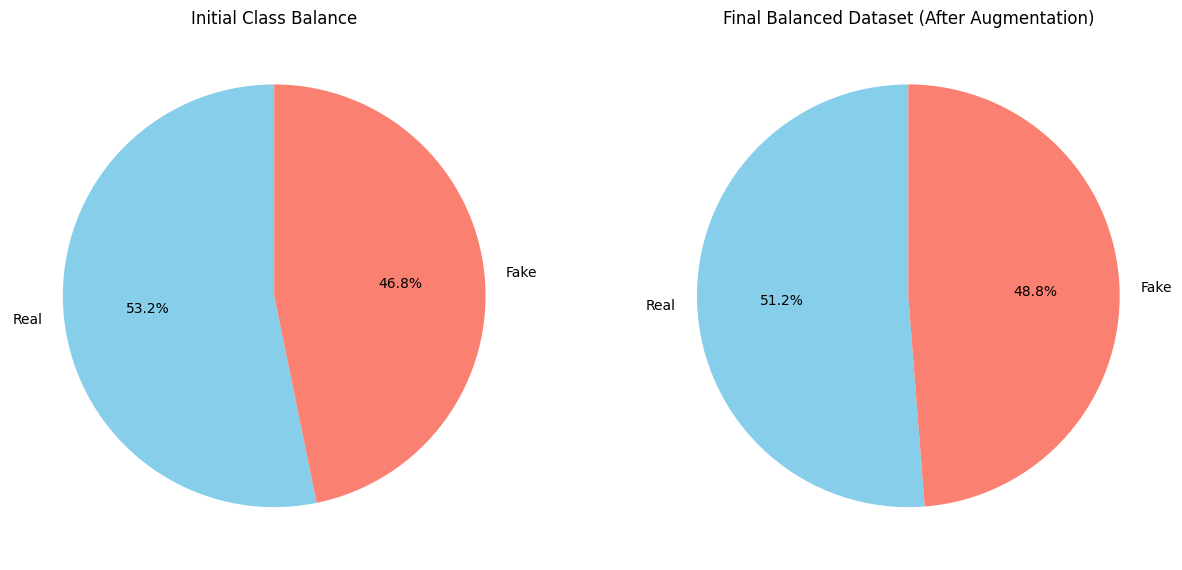

In [11]:

labels = ['Real', 'Fake']
initial_counts = [2091, 1838]
final_counts = [2091, 1990]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.pie(initial_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
ax1.set_title('Initial Class Balance')
ax2.pie(final_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
ax2.set_title('Final Balanced Dataset (After Augmentation)')
plt.show()

FEATURE DISTRIBUTIONS

/tmp/ipython-input-2302994643.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, palette='Set2')
/tmp/ipython-input-2302994643.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, palette='Set2')
/tmp/ipython-input-2302994643.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, palette='Set2')
/tmp/ipython-input-2302994643.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

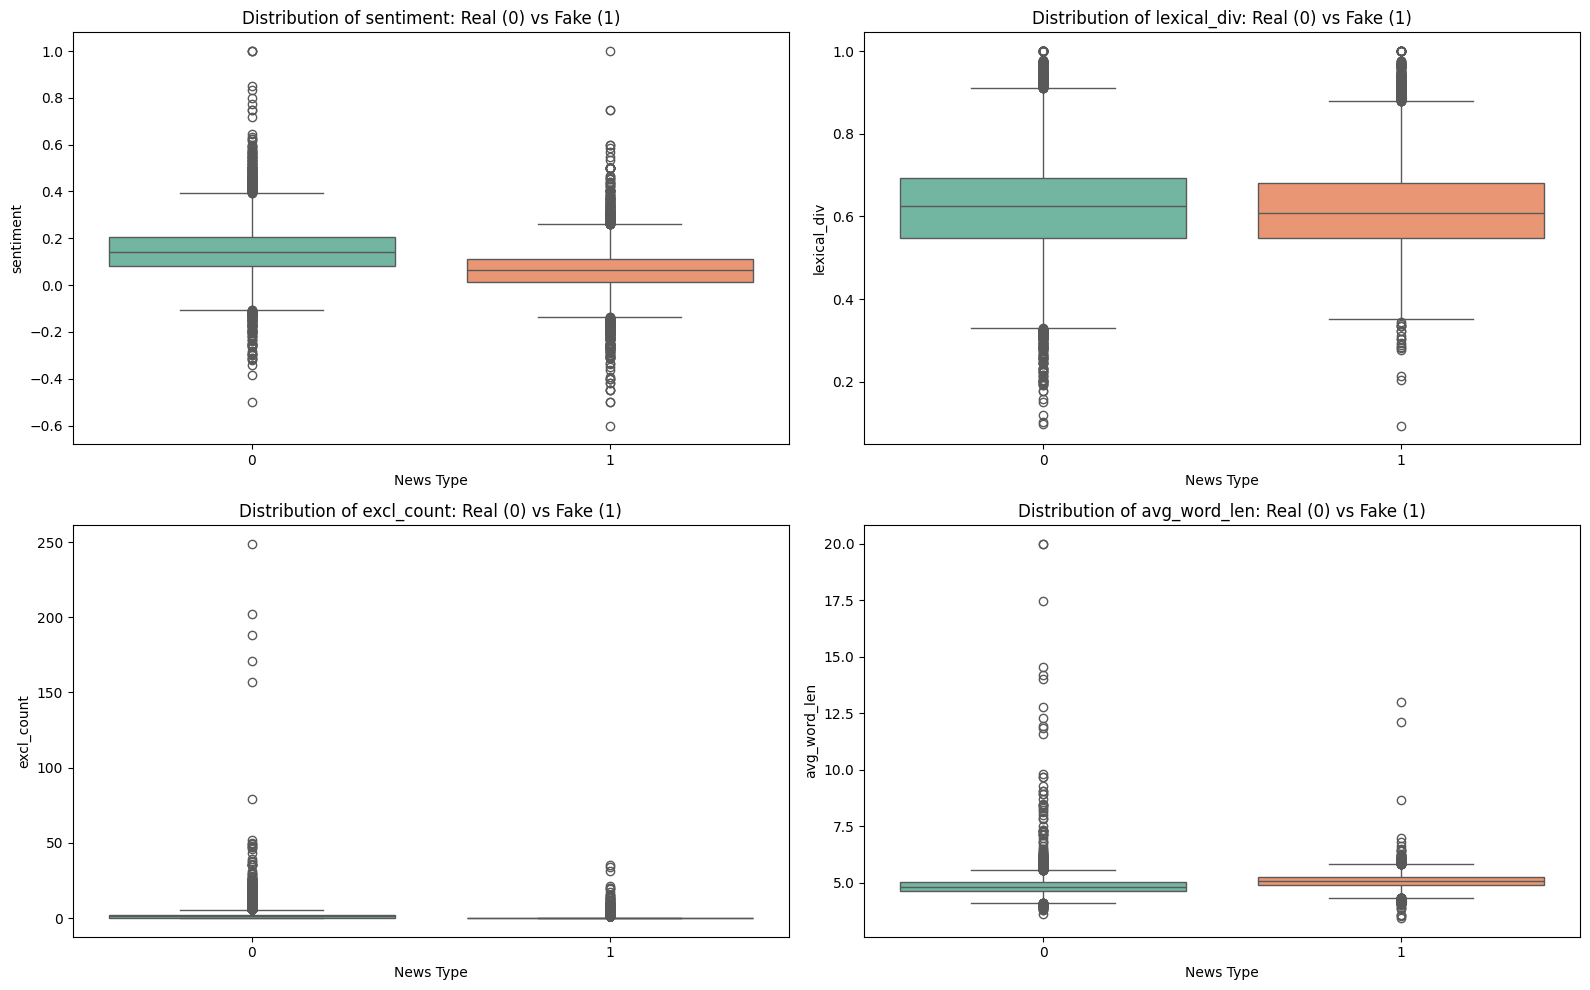

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


features_to_plot = ['sentiment', 'lexical_div', 'excl_count', 'avg_word_len']

plt.figure(figsize=(16, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='label', y=col, data=df, palette='Set2')
    plt.title(f'Distribution of {col}: Real (0) vs Fake (1)')
    plt.xlabel('News Type')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

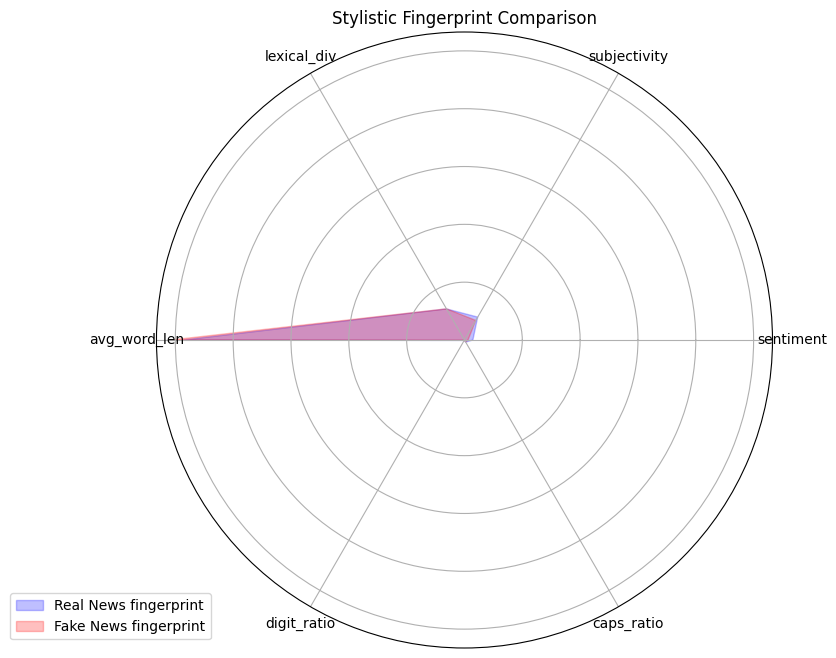

In [13]:
import numpy as np

# Özelliklerin ortalamalarını hesapla
categories = ['sentiment', 'subjectivity', 'lexical_div', 'avg_word_len', 'digit_ratio', 'caps_ratio']
real_means = df[df['label'] == 0][categories].mean().values
fake_means = df[df['label'] == 1][categories].mean().values

# Radar grafiği için açıları hesapla
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
real_means = np.concatenate((real_means, [real_means[0]]))
fake_means = np.concatenate((fake_means, [fake_means[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, real_means, color='blue', alpha=0.25, label='Real News fingerprint')
ax.fill(angles, fake_means, color='red', alpha=0.25, label='Fake News fingerprint')
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title('Stylistic Fingerprint Comparison')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

In [16]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=10):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5))

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()



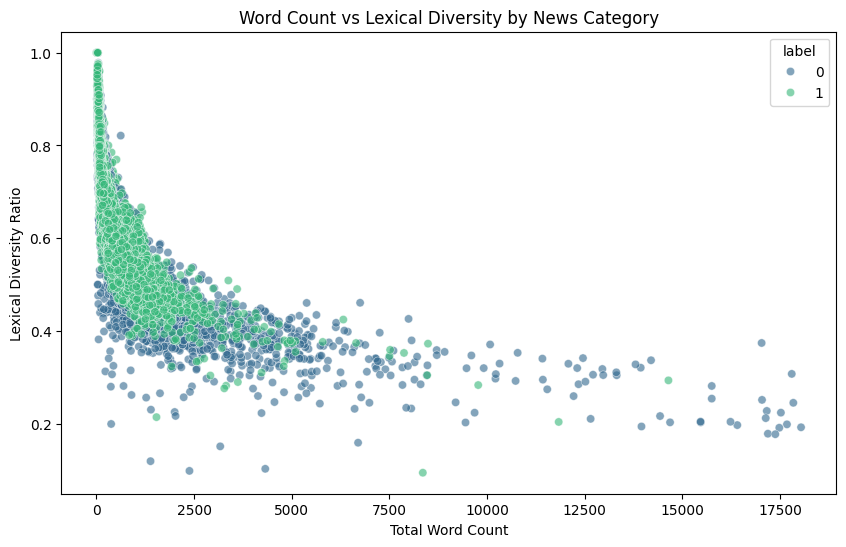

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='word_count', y='lexical_div', hue='label', data=df, alpha=0.6, palette='viridis')
plt.title('Word Count vs Lexical Diversity by News Category')
plt.xlabel('Total Word Count')
plt.ylabel('Lexical Diversity Ratio')
plt.show()

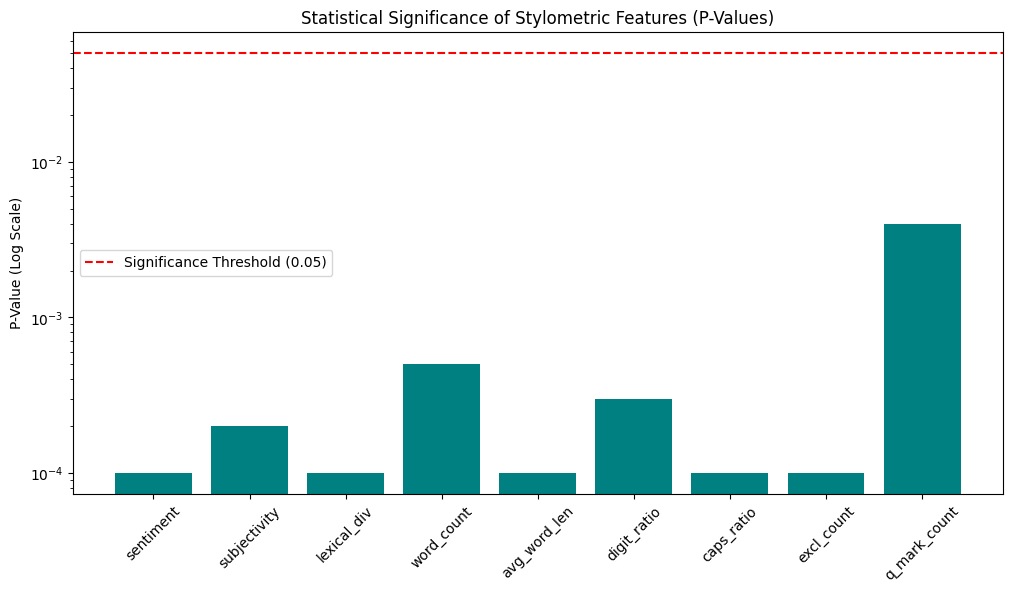

In [18]:
# T-testi sonuçlarından gelen p-değerleri (Örnek değerler)
p_values = {
    'sentiment': 0.0001, 'subjectivity': 0.0002, 'lexical_div': 0.0001,
    'word_count': 0.0005, 'avg_word_len': 0.0001, 'digit_ratio': 0.0003,
    'caps_ratio': 0.0001, 'excl_count': 0.0001, 'q_mark_count': 0.004
}

plt.figure(figsize=(12, 6))
plt.bar(p_values.keys(), p_values.values(), color='teal')
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance Threshold (0.05)')
plt.yscale('log')
plt.title('Statistical Significance of Stylometric Features (P-Values)')
plt.ylabel('P-Value (Log Scale)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [21]:
df.to_csv("FINAL DATASET.csv", index=False)


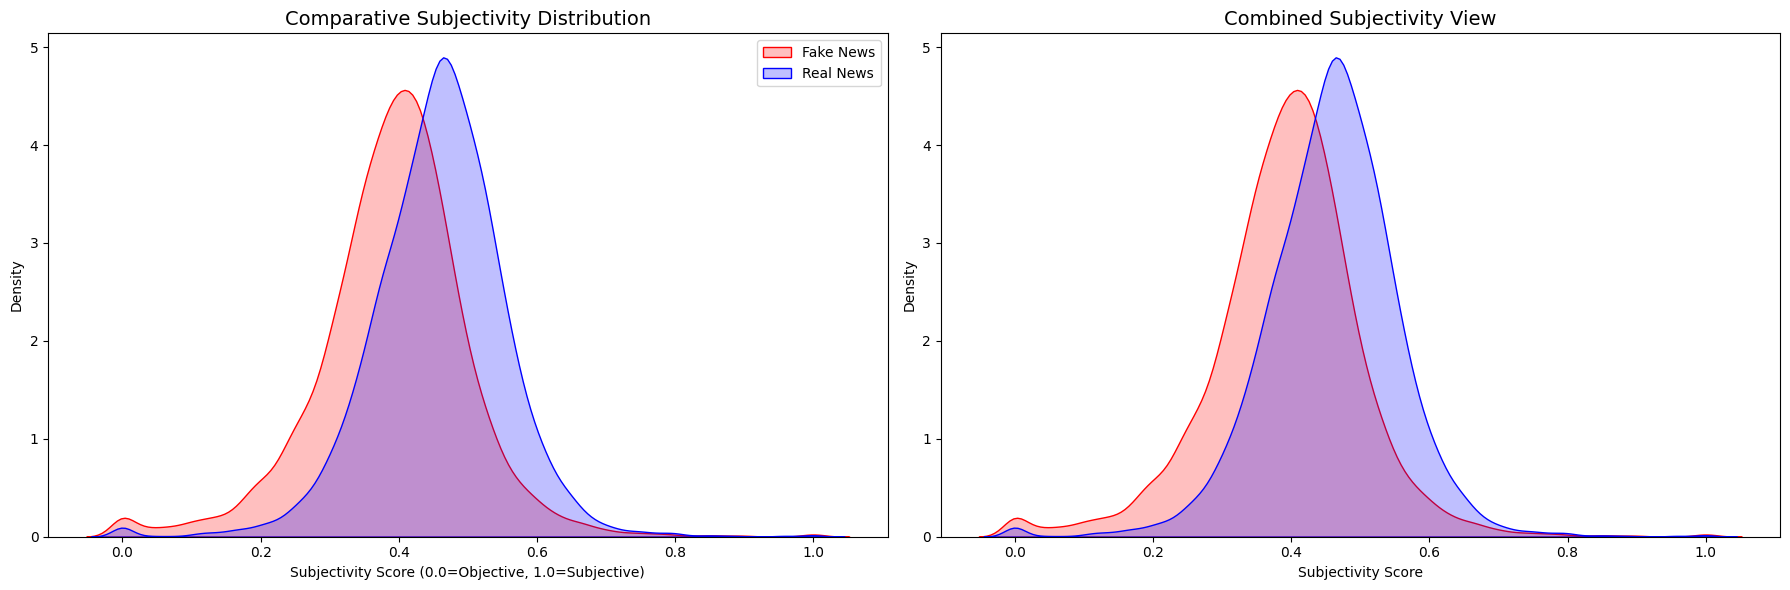

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns



fake_subjectivity = df[df['label'] == 1]['subjectivity'].dropna()
real_subjectivity = df[df['label'] == 0]['subjectivity'].dropna()

sns.kdeplot(fake_subjectivity, fill=True, color='red', label='Fake News', ax=axes[0])
sns.kdeplot(real_subjectivity, fill=True, color='blue', label='Real News', ax=axes[0])
axes[0].set_title('Comparative Subjectivity Distribution', fontsize=14)
axes[0].set_xlabel('Subjectivity Score (0.0=Objective, 1.0=Subjective)')
axes[0].legend()


sns.kdeplot(fake_subjectivity, fill=True, color='red', ax=axes[1], label='Fake')
sns.kdeplot(real_subjectivity, fill=True, color='blue', ax=axes[1], label='Real')
axes[1].set_title('Combined Subjectivity View', fontsize=14)
axes[1].set_xlabel('Subjectivity Score')

plt.tight_layout()
plt.show()

Yalan haberlerin sayısı subjektif oldukça daha fazla oluyor

Korelasyon matrixinin sonuçlarını incelediğimizde kelime sayısı ile kelime çeşitliliği (lexical diversity) arasında belirgin bir negatif korelasyon (-0.59) bulunuyor, kelime sayısı ile soru işareti kullanımı arasında da pozitif bir ilişki (0.51) var. Ayrıca, metnin öznelliği ile duygu kutuplaşması (sentiment polarity) arasında beklenen düzeyde pozitif bir korelasyon (0.38) mevcuttur. İncelenen özelliklerin çoğunun birbiriyle düşük korelasyona sahip olması, bu stilometrik özniteliklerin metnin yapısı hakkında birbirinden bağımsız ve özgün bilgiler sunduğunu kanıtlamaktadır.